In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats

## Question 3
Each month the Bureau of Labor Statistics in the U.S. Department of Labor conducts the
Current Population Survey (CPS), which provides data on labor force characteristics of the population,
including the level of employment, unemployment, and earnings. Approximately 65,000 randomly
selected U.S. households are surveyed each month. The sample is chosen by randomly selecting
addresses from a database comprised of addresses from the most recent decennial census augmented
with data on new housing units constructed after the last census. The exact random sampling scheme
is rather complicated (first small geographical areas are randomly selected, then housing units within
these areas randomly selected); details can be found in the Handbook of Labor Statistics and is
described on the Bureau of Labor Statistics website (www.bls.gov). For this exercise, you
will utilize the
data set called cpsDATA.csv . You
will investigate the relationship between a worker’s age and earnings.
##### a. Construct a scatter-plot of (average hourly) earnings ahe against age . Does there appear to be a relationship between the variables?
##### b. Run a regression of (average hourly) earnings on age. What is the estimated intercept? What is the estimated slope? How much do earnings increase as workers age by 1 year?
##### c. Troy is a 26 year old worker. Predict Troy’s earnings using the estimated regression. Abed is a 30 year old worker. Predict Abed’s earnings using the estimated regression.
##### d. Does age account for a large fraction of the variance in earnings across individuals? Explain.

In [96]:
CPSData = pd.read_csv('cpsDATA.csv')

In [97]:
CPSData.head()

,ahe,yrseduc,female,age,northeast,midwest,south,west
0,21.367521,13,1,65,1,0,0,0
1,24.038462,16,0,56,1,0,0,0
2,7.692307,12,0,42,1,0,0,0
3,15.182186,12,1,42,1,0,0,0
4,20.614346,14,1,53,1,0,0,0


In [98]:
CPSData[['ahe','age']].describe()

,ahe,age
count,59668.000000,59668.000000
mean,25.213722,42.884846
std,17.288963,12.583984
min,2.000000,15.000000
25%,13.736263,33.000000
50%,20.192308,42.000000
75%,31.250000,52.000000
max,228.365387,85.000000


In [99]:
CPSData[['ahe','age']].corr()

,ahe,age
ahe,1.000000,0.180542
age,0.180542,1.000000


In [100]:
CPSData[['ahe','age']].cov()

,ahe,age
ahe,298.908253,39.279371
age,39.279371,158.356642


In [103]:
model = smf.ols(formula='ahe ~ age', data=CPSData)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    ahe   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     2010.
Date:                Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:04:18   Log-Likelihood:            -2.5373e+05
No. Observations:               59668   AIC:                         5.075e+05
Df Residuals:                   59666   BIC:                         5.075e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     14.5764      0.247     58.955      0.0

In [102]:
SER = np.sqrt(np.sum(results.resid**2)/results.df_resid)

In [34]:
SER

np.float64(17.00500215134809)

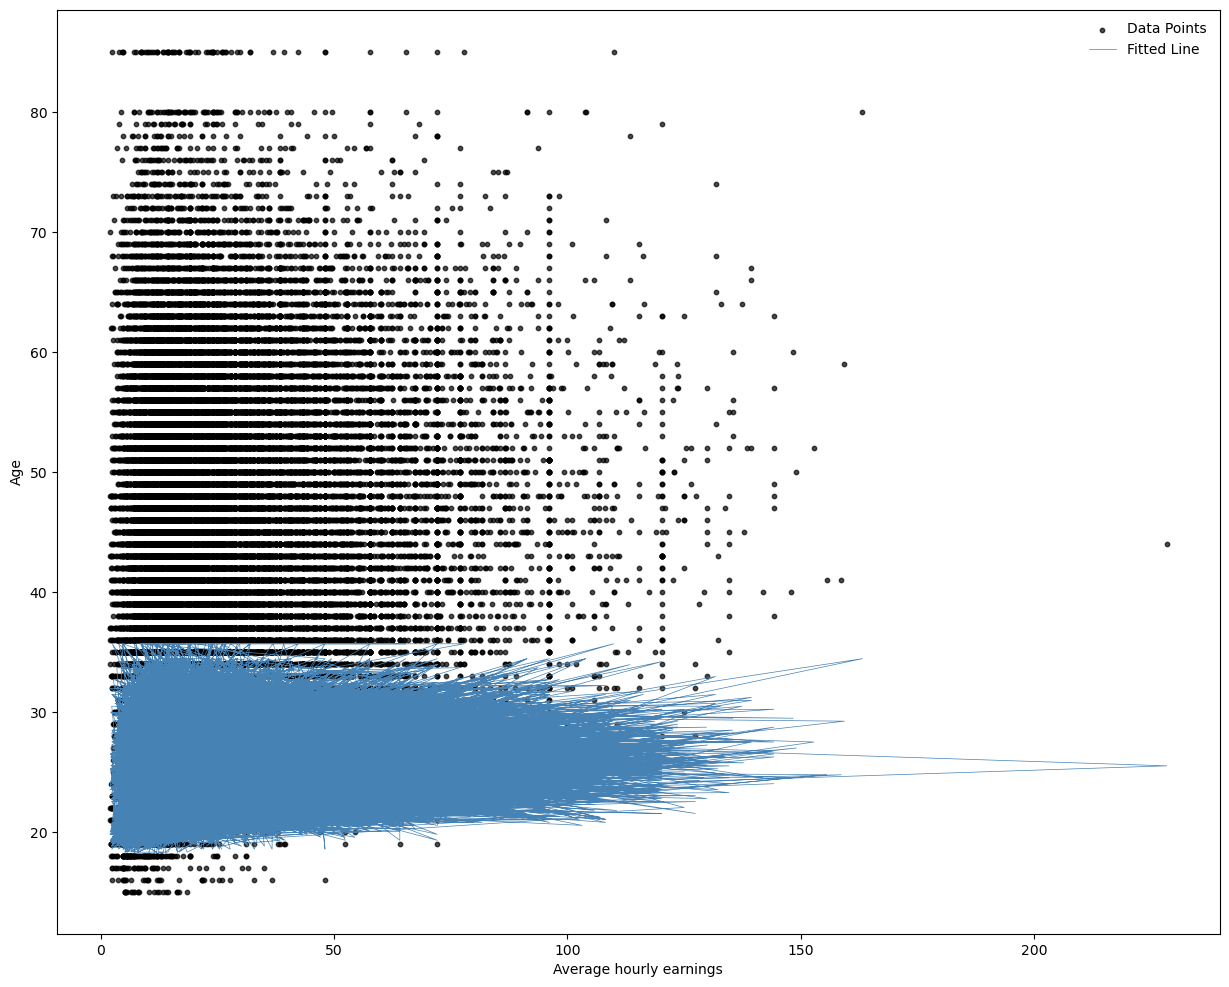

In [35]:
fig, ax = plt.subplots(figsize=(15, 12))
ax.scatter(CPSData['age'], CPSData['ahe'], color = 'black', label = 'Data Points', alpha = 0.7, s = 10)
ax.plot(CPSData['age'], results.fittedvalues, color = 'steelblue', label = 'Fitted Line', linewidth = 0.5)
ax.set_xlabel('Average hourly earnings')
ax.set_ylabel('Age')
ax.legend(frameon = False)
plt.show()

####  a) With the scatter plot and fitted line created above, it is shown that there is no true correlation between age and average hourly earnings. So, there is no true relationship between the variables.

#### b) The estimated intercept is approximately 14.5764. The estimated slope is approximately 0.248. As workers age by one year, their earnings increase by about 25 cents. 

#### d) No, age does not account for the large fraction of variance across earnings in individuals. This is because there are other factors that can contribute to earnings, such as education and previous experience, which can impact someone's earnings.

## Question 4
In this exercise, you will use the data file TeachingRatings.xlsx , which contains data on course evaluations, course characteristics, and professor characteristics for 463 courses for the academic years 2000-2002 at the University of Texas at Austin. These data were provided by Professor Daniel Hamermesh of the University of Texas at Austin and were used in his paper with Hamermesh and Parker (2005). See also the pdf file TeachingRatingsDescription.pdf for variable definitions.
##### a. Construct a scatter-plot of average course evaluations (course_eval ) on the professor’s beauty (beauty ). Does there appear to be a relationship between the variables?
##### b. Run a regression of average course evaluations (course_eval ) on the professor’s beauty (beauty ). What is the estimated intercept? What is the estimated slope? Explain why the estimated intercept is equal to the sample mean of (course_eval ). (Hint: What is the sample mean of beauty?)
##### c. Professor Hawthorne has an average value of beauty, while Professor Winger’s value of beauty is one standard deviation above the average. Predict Professor Winger’s and Professor Hawthorne’s course evaluations.
##### d. Is the estimated effect of beauty on course evaluations large or small? Explain what you mean by large or small.
##### e. Does beauty explain a large fraction of the variance in course evaluations across courses? Explain.

In [78]:
tr = pd.read_excel("TeachingRatings.xlsx", sheet_name = 0)

/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [79]:
tr.head()

,minority,age,female,onecredit,beauty,course_eval,intro,nnenglish
0,1,36,1,0,0.289916,4.3,0,0
1,0,59,0,0,-0.737732,4.5,0,0
2,0,51,0,0,-0.571984,3.7,0,0
3,0,40,1,0,-0.677963,4.3,0,0
4,0,31,1,0,1.509794,4.4,0,0


In [80]:
tr[['course_eval','beauty']].describe()

,course_eval,beauty
count,463.000000,4.630000e+02
mean,3.998272,6.263499e-08
std,0.554866,7.886477e-01
min,2.100000,-1.450494e+00
25%,3.600000,-6.562689e-01
50%,4.000000,-6.801430e-02
75%,4.400000,5.456024e-01
max,5.000000,1.970023e+00


In [81]:
tr[['course_eval','beauty']].corr()

,course_eval,beauty
course_eval,1.000000,0.189039
beauty,0.189039,1.000000


In [82]:
tr[['course_eval','beauty']].cov()

,course_eval,beauty
course_eval,0.307876,0.082722
beauty,0.082722,0.621965


In [83]:
model = smf.ols(formula='course_eval ~ beauty', data=tr)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            course_eval   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     17.08
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           4.25e-05
Time:                        17:41:42   Log-Likelihood:                -375.32
No. Observations:                 463   AIC:                             754.6
Df Residuals:                     461   BIC:                             762.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.9983      0.025    157.727      0.0

In [85]:
SER = np.sqrt(np.sum(results.resid**2)/results.df_resid)

In [86]:
SER

np.float64(0.5454517323791509)

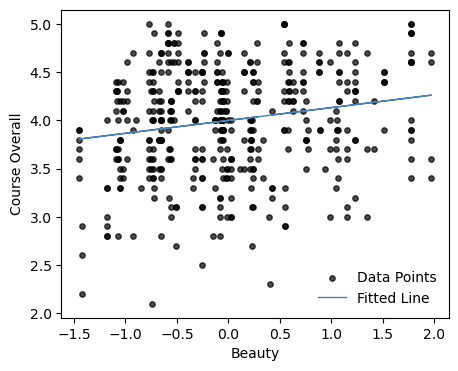

In [91]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(tr['beauty'], tr['course_eval'], color = 'black', label = 'Data Points', alpha = 0.7, s = 15)
ax.plot(tr['beauty'], results.fittedvalues, color = 'steelblue', label = 'Fitted Line', linewidth = 1)
ax.set_xlabel('Beauty')
ax.set_ylabel('Course Overall')
ax.legend(frameon = False)
plt.show()

#### a) No, there doesn't seem to be a relationship between the variables.

#### b) The estimated intercept is 3.9983 and the estimated slope is 0.1330. The estimated intercept is equal to the sample mean because the variable beauty is shifted to have mean 0.

#### d) The estimated effect of beauty on course evaluations is small as the variance of the correlation of beauty on course evaluation is only 0.036, or 3.6%.

#### e) No, it does not explain a large fraction of the course evaluations. As explained before, the variance of the correlation of beauty on course evaluations is only 3.6% which is a small percentage.